<a href="https://colab.research.google.com/github/MalgosiaKacp/lecture1/blob/main/Por%C3%B3wnanieKlasyfikator%C3%B3w.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import RocCurveDisplay, roc_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import auc

In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
y = data.target #list(data.target_names)
X = data.data #data.feature_names

1. Sprawdź liczbę wszystkich przypadków
2. Sprawdź liczbę przypadków raka złośliwego
3. Narysuj histogram średniego obszaru (mean area)
4. Narysuj wykres rozrzutu (scatterplot) średniego obszaru od klasyfikacji (użyj
sns.regplot)

In [3]:
# wszystkie przypadki
X.shape

(569, 30)

In [4]:

data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [5]:
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [6]:
# rak złośliwy
sum(y)

np.int64(357)

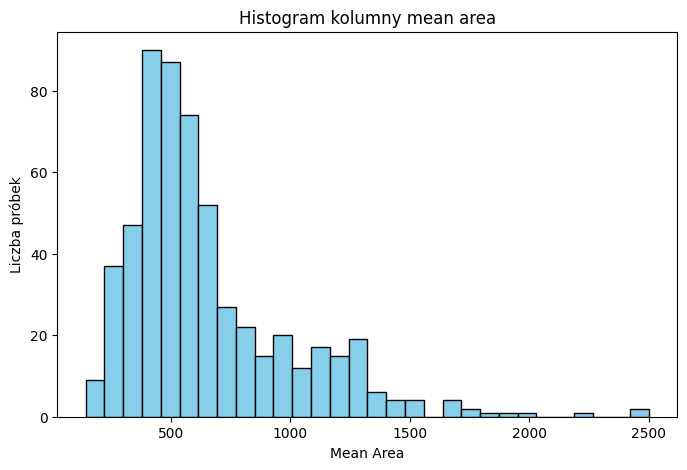

In [7]:
# histogram

col_index = list(data.feature_names).index('mean area')

plt.figure(figsize=(8,5))
plt.hist(X[:, col_index], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram kolumny mean area')
plt.xlabel('Mean Area')
plt.ylabel('Liczba próbek')
plt.show()

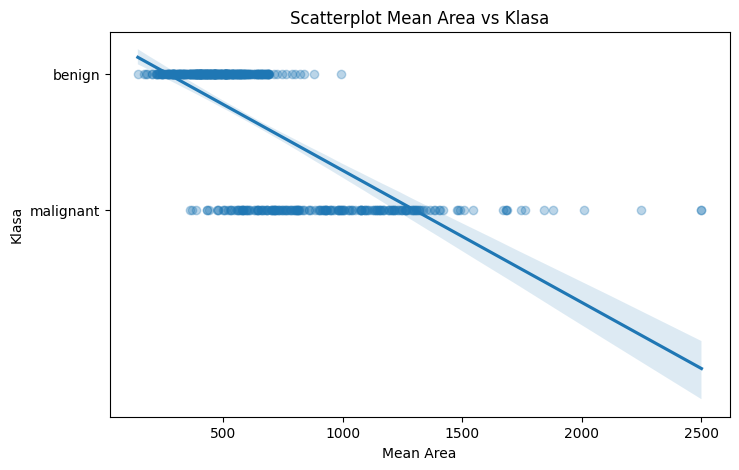

In [8]:
# wykres rozrzutu
plt.figure(figsize=(8,5))
sns.regplot(
    y=y,
    x=X[:, col_index],
    scatter=True,
    fit_reg=True,
    scatter_kws={'alpha':0.3}
)
plt.yticks([0,1], ['malignant', 'benign'])
plt.ylabel('Klasa')
plt.xlabel('Mean Area')
plt.title('Scatterplot Mean Area vs Klasa')
plt.show()

Zbuduj model regresji logistycznej
1. Sprawdź, jeśli dane nie są ustandaryzowane zrób to
2. Podziel zbiór danych na testowy (30%) i uczący (70%)
3. Zwizualizuj wyniki używając:

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from sklearn.metrics import RocCurveDisplay, roc_curve

In [9]:
# standaryzacja
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [10]:
# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# Regresja logistyczna

In [11]:
# regresja logistyczna
clf = LogisticRegression(random_state=100).fit(X_train, y_train)

y_pred = clf.predict(X_test)

y_prob = clf.predict_proba(X_test)[:, 1]

print("Przewidywane klasy:", y_pred[:5])
print("Prawdopodobieństwa klasy '1':", y_prob[:5])

Przewidywane klasy: [1 0 0 1 1]
Prawdopodobieństwa klasy '1': [8.80588135e-01 1.45190673e-05 3.46906858e-03 9.99439449e-01
 9.99911697e-01]


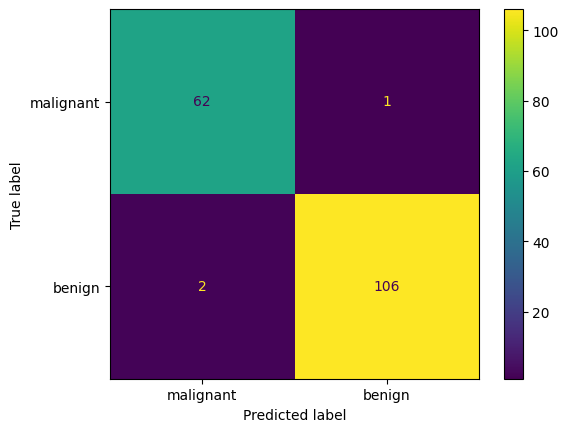

In [12]:
# wykres
display_labels = data.target_names
cm_lr = confusion_matrix(y_test ,y_pred)

ConfusionMatrixDisplay(cm_lr, display_labels=display_labels).plot()

In [13]:
# raport
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98        63
           1       0.99      0.98      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



Text(0.5, 1.0, 'ROC curve')

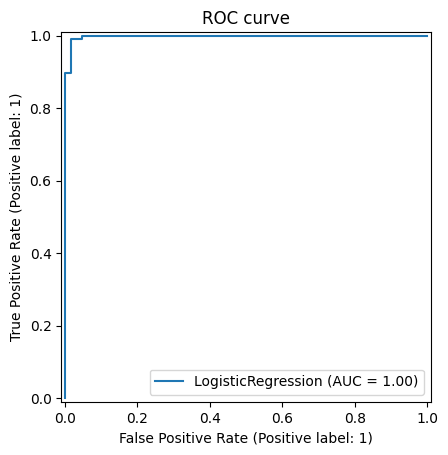

In [14]:
# ROC
RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.title('ROC curve')

# KNN

Przewidywane klasy: [1 0 0 1 1]
Prawdopodobieństwa klasy '1': [1. 0. 0. 1. 1.]
              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



Text(0.5, 1.0, 'ROC curve')

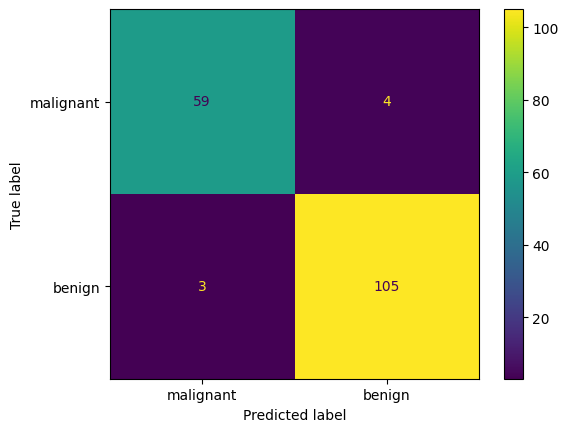

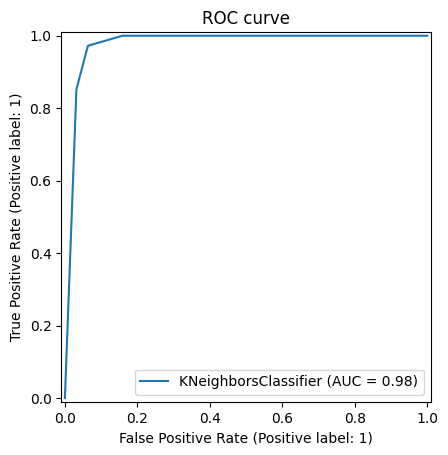

In [15]:
# K - sąsiedzi (5)
neigh = KNeighborsClassifier(n_neighbors=5)
neigh.fit(X_train, y_train)
y_pred = neigh.predict(X_test)
y_prob = neigh.predict_proba(X_test)[:, 1]
print("Przewidywane klasy:", y_pred[:5])
print("Prawdopodobieństwa klasy '1':", y_prob[:5])

display_labels = data.target_names
cm = confusion_matrix(y_test ,y_pred)

ConfusionMatrixDisplay(cm, display_labels=display_labels).plot()

print(classification_report(y_test, y_pred))

RocCurveDisplay.from_estimator(neigh, X_test, y_test)
plt.title('ROC curve')

Przewidywane klasy: [1 0 0 1 1]
Prawdopodobieństwa klasy '1': [1. 0. 0. 1. 1.]
              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



Text(0.5, 1.0, 'ROC curve')

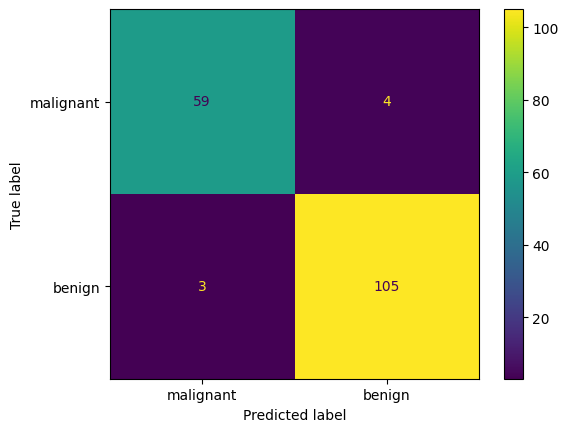

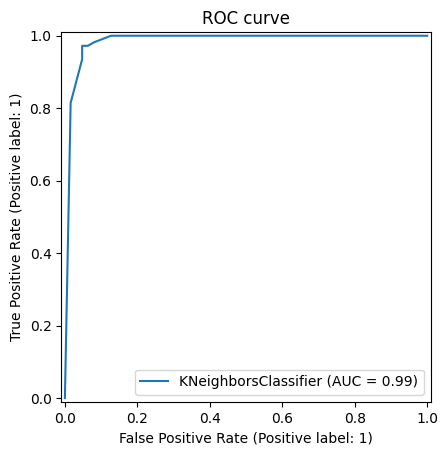

In [16]:
# K - sąsiedzi (7)
neigh = KNeighborsClassifier(n_neighbors=7)
neigh.fit(X_train, y_train)
y_pred = neigh.predict(X_test)
y_prob = neigh.predict_proba(X_test)[:, 1]
print("Przewidywane klasy:", y_pred[:5])
print("Prawdopodobieństwa klasy '1':", y_prob[:5])

display_labels = data.target_names
cm = confusion_matrix(y_test ,y_pred)

ConfusionMatrixDisplay(cm, display_labels=display_labels).plot()

print(classification_report(y_test, y_pred))

RocCurveDisplay.from_estimator(neigh, X_test, y_test)
plt.title('ROC curve')

# Klasyfikator Bayesa

In [17]:
from sklearn.naive_bayes import GaussianNB
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

gnb = GaussianNB()
y_pred = gnb.fit(X_train, y_train).predict(X_test)

print("Wyniki klasyfikacji Bayesa:")
print(classification_report(y_test, y_pred))

Wyniki klasyfikacji Bayesa:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91        63
           1       0.94      0.95      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



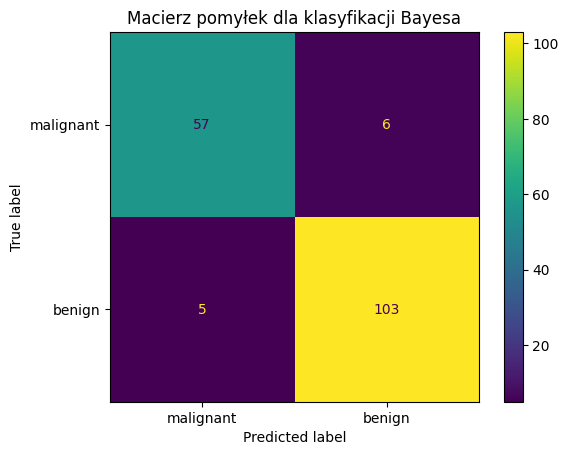

In [18]:
display_labels = data.target_names
cm_rf = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=display_labels).plot()
plt.title('Macierz pomyłek dla klasyfikacji Bayesa')
plt.show()

Text(0.5, 1.0, 'ROC curve')

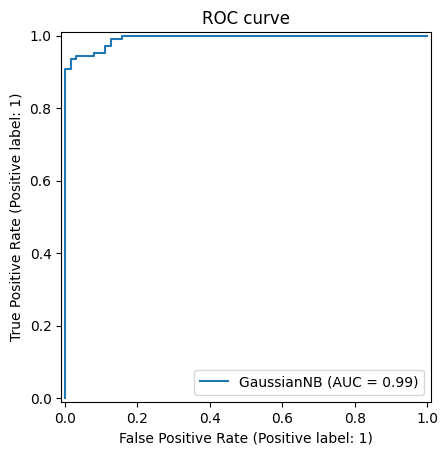

In [19]:
RocCurveDisplay.from_estimator(gnb.fit(X_train, y_train), X_test, y_test)
plt.title('ROC curve')

# Drzewo decyzyjne

In [20]:
# Drzewo decyzyjne
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=0)
cross_val_score(clf, X, y, cv=15) # accuracy score

array([0.97368421, 0.92105263, 0.86842105, 0.94736842, 0.89473684,
       0.86842105, 0.89473684, 0.94736842, 0.92105263, 0.81578947,
       0.94736842, 0.92105263, 0.89473684, 1.        , 0.91891892])

In [21]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Wyniki dla drzewa decyzyjnego:")
print(classification_report(y_test, y_pred))

Wyniki dla drzewa decyzyjnego:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        63
           1       0.97      0.91      0.94       108

    accuracy                           0.92       171
   macro avg       0.91      0.93      0.92       171
weighted avg       0.93      0.92      0.92       171



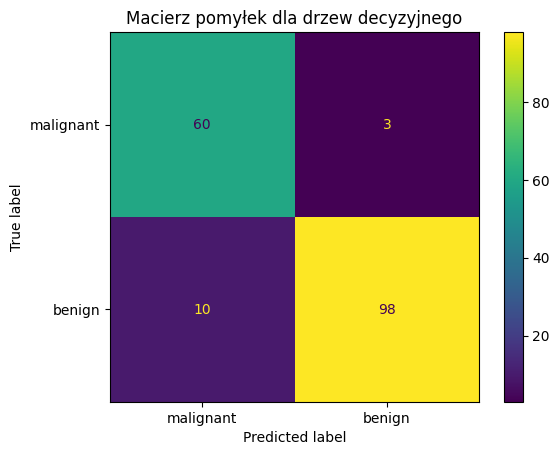

In [22]:
display_labels = data.target_names
cm_rf = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=display_labels).plot()
plt.title('Macierz pomyłek dla drzew decyzyjnego')
plt.show()

Text(0.5, 1.0, 'ROC curve')

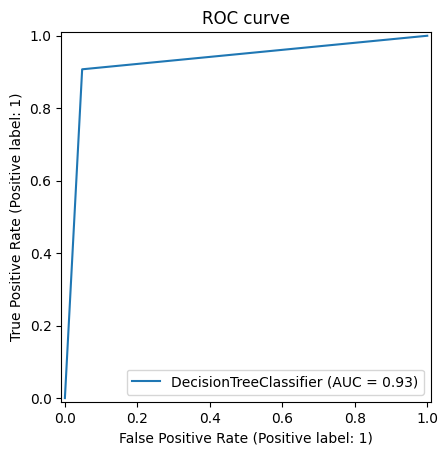

In [23]:
RocCurveDisplay.from_estimator(clf.fit(X_train, y_train), X_test, y_test)
plt.title('ROC curve')

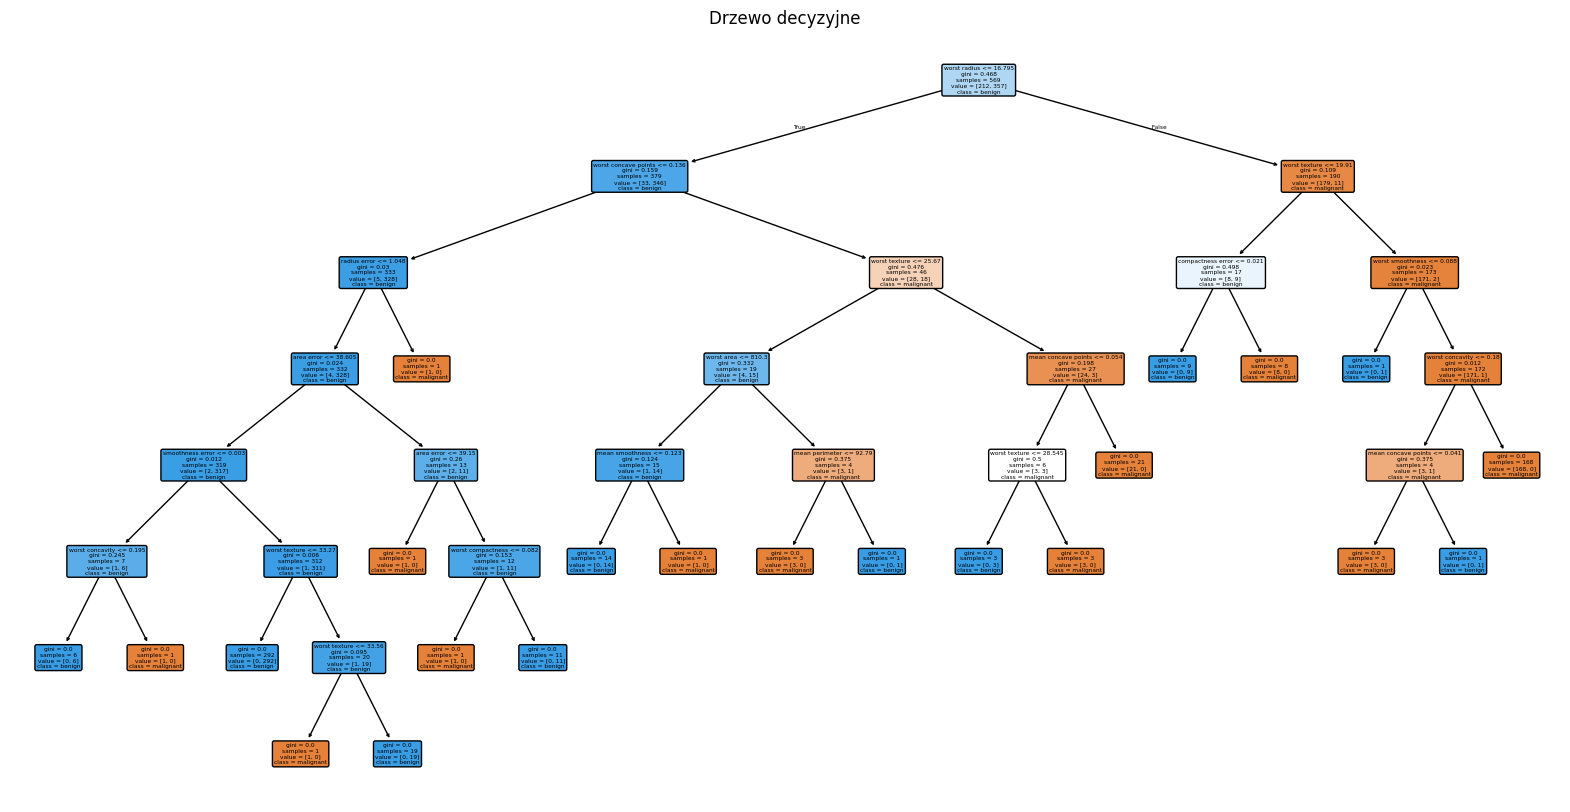

In [24]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
clf.fit(X, y)
plot_tree(clf, feature_names=data.feature_names, class_names=data.target_names, filled=True, rounded=True)
plt.title('Drzewo decyzyjne')
plt.show()

# Las drzew

In [25]:
# Las drzew
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

clf = RandomForestClassifier(n_estimators=15, max_depth=2, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Wyniki dla lasu drzew:")
print(classification_report(y_test, y_pred))

Wyniki dla lasu drzew:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93        63
           1       0.95      0.97      0.96       108

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



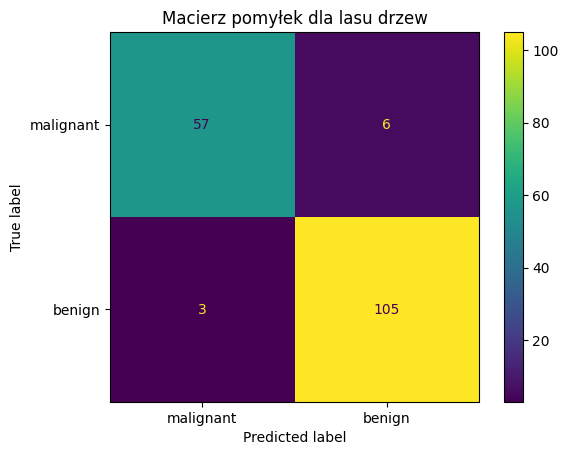

In [26]:

display_labels = data.target_names
cm_rf = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=display_labels).plot()
plt.title('Macierz pomyłek dla lasu drzew')
plt.show()

Text(0.5, 1.0, 'ROC curve')

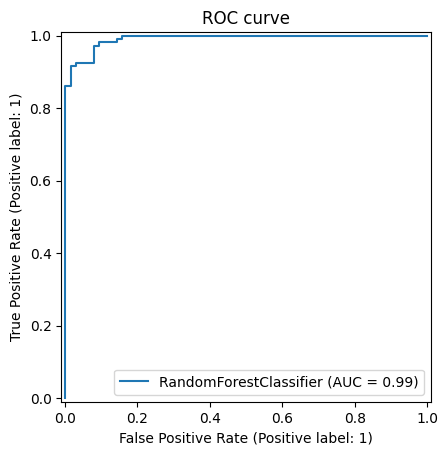

In [27]:
RocCurveDisplay.from_estimator(clf.fit(X_train, y_train), X_test, y_test)
plt.title('ROC curve')

### Podsumowanie Użytych Klasyfikatorów

1.  **Regresja logistyczna**:
    *   Model wyróżnił się wysoką dokładnością na poziomie **0.98**.

2.  **KNN**:
    *   Dla `k=5` i `k=7`, model KNN osiągnął dokładność **0.96**, co jest również bardzo dobrym wynikiem.

3.  **Naiwny klasyfikator Bayesa**:
    *   Osiągnął dokładność **0.94**, co jest wynikiem nieco niższym niż regresja logistyczna i KNN.

4.  **Drzewo decyzyjne**:
    *   Osiągnęło dokładność **0.92**.

5.  **Las drzew**:
    *   Z dokładnością **0.95**, las drzew pokazał wyniki, zbliżone do KNN i regresji logistycznej.

#### Wniosek:
Ogólnie rzecz biorąc, wszystkie użyte klasyfikatory osiągnęły wysokie wyniki w klasyfikacji raka, przy czym regresja logistyczna i KNN wydają się być nieco lepsze pod względem ogólnej dokładności na tym zbiorze danych.